In [1]:
import numpy as np
# Patch for NumPy >= 1.24 where np.bool8 was removed
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_
if not hasattr(np, "np.float_"):
    np.float_ = np.float64
if not hasattr(np, "np.complex_"):
    np.complex_ = np.complex128
if not hasattr(np, "np.unicode_"):
    np.unicode_ = np.str_

import torch
# Quick patch for PyTorch 2.6+ to fix UnpicklingError
orig_torch_load = torch.load
torch.load = lambda f, *args, **kwargs: orig_torch_load(f, *args, weights_only=False, **kwargs)

In [2]:
from recbole.quick_start import run_recbole

config_dict = {
    'show_progress' : False
}

run_recbole(model='BPR', dataset='ml-100k', config_dict=config_dict)

24 Sep 16:17    INFO  ['c:\\Users\\martin\\miniconda3\\envs\\bp\\Lib\\site-packages\\ipykernel_launcher.py', '--f=c:\\Users\\martin\\AppData\\Roaming\\jupyter\\runtime\\kernel-v3e8856de344f1f819d3cb1ea81d78acf7b69c7332.json']
24 Sep 16:17    INFO  
General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 2020
state = INFO
reproducibility = True
data_path = C:\Users\martin\miniconda3\envs\bp\Lib\site-packages\recbole\config\../dataset_example/ml-100k
checkpoint_dir = saved
show_progress = False
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = False

Training Hyper Parameters:
epochs = 300
train_batch_size = 2048
learner = adam
learning_rate = 0.001
train_neg_sample_args = {'distribution': 'uniform', 'sample_num': 1, 'alpha': 1.0, 'dynamic': False, 'candidate_num': 0}
eval_step = 1
stopping_step = 10
clip_grad_norm = None
weight_decay = 0.0
loss_decimal_place = 4

Evaluation Hyper Parameters:
eval_args = {'split': {'RS': [0

{'best_valid_score': np.float64(0.3893),
 'valid_score_bigger': True,
 'best_valid_result': OrderedDict([('recall@10', np.float64(0.2085)),
              ('mrr@10', np.float64(0.3893)),
              ('ndcg@10', np.float64(0.2302)),
              ('hit@10', np.float64(0.7402)),
              ('precision@10', np.float64(0.1583))]),
 'test_result': OrderedDict([('recall@10', np.float64(0.2466)),
              ('mrr@10', np.float64(0.4895)),
              ('ndcg@10', np.float64(0.2928)),
              ('hit@10', np.float64(0.7815)),
              ('precision@10', np.float64(0.1962))])}

In [3]:
# pip install -U tqdm ipywidgets ipython

# pip install -U jupyter ipywidgets widgetsnbextension notebook

In [ ]:
log_file = "log/BPR/BPR-ml-100k-Sep-24-2025_16-17-26-6c81b6.log"  # <-- change this if needed

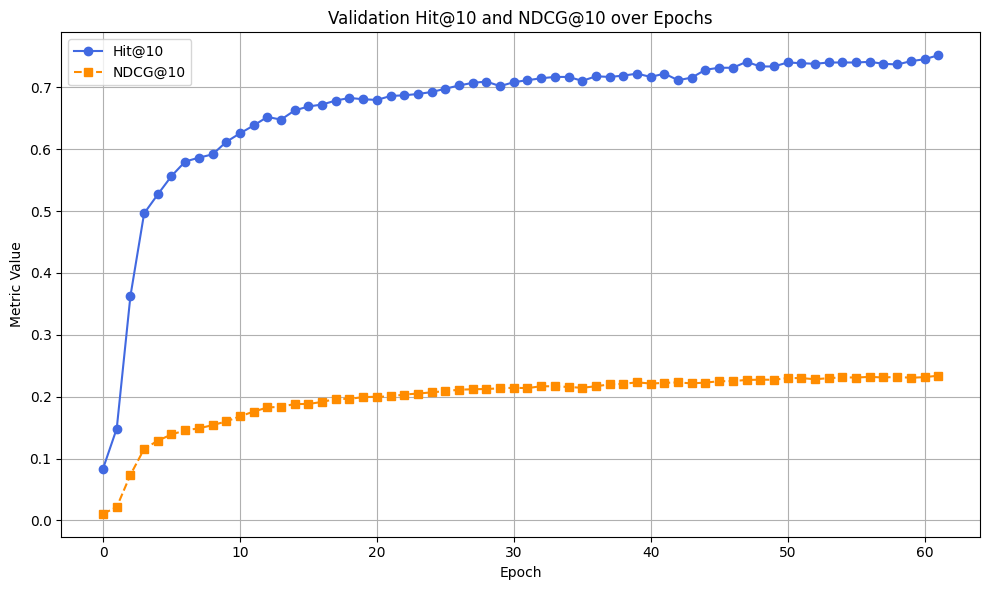

In [ ]:
import re
import matplotlib.pyplot as plt

hit_values = []
ndcg_values = []

with open(log_file, "r") as f:
    for line in f:
        hit_match = re.search(r"hit@10\s*:\s*([\d.]+)", line)
        ndcg_match = re.search(r"ndcg@10\s*:\s*([\d.]+)", line)

        if hit_match:
            hit_values.append(float(hit_match.group(1)))
        if ndcg_match:
            ndcg_values.append(float(ndcg_match.group(1)))

# Make sure both lists are the same length
#epochs = range(min(len(hit_values), len(ndcg_values)))
epochs = range(0, len(hit_values))

# Plot Hit@10 and NDCG@10
plt.figure(figsize=(10, 6))
#plt.plot(epochs, hit_values[:len(epochs)], marker='o', linestyle='-', color='royalblue', label='Hit@10')
plt.plot(epochs, hit_values, marker='o', linestyle='-', color='royalblue', label='Hit@10')
plt.plot(epochs, ndcg_values, marker='s', linestyle='--', color='darkorange', label='NDCG@10')
plt.title("Validation Hit@10 and NDCG@10 over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()